## 우리금융 실습 1주차

- 패키지 설치

In [1]:
# !pip install scipy
# !pip install statsmodels
# !pip install matplotlib
# !pip install mlxtend

In [2]:
import numpy as np
import pandas as pd

from scipy.stats import beta, binom, cauchy, chi2, expon, f, gamma, geom, hypergeom, lognorm, logistic, nbinom, norm, poisson, t, weibull_min, wilcoxon, ttest_ind
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

### 1. 분포

- 자주 쓰이는 확률분포의 확률값이나 밀도함수를 구해주고, 특정 분포를 따르는 난수를 생성한다.
- 지원되는 분포의 종류
- Beta, binomial, Cauchy, chi-square, exponential, F, gamma, geometric, hypergeometric, log-normal, logistic, negative, normal, Poisson, Student’s t, uniform, Weibull, Wilcoxon


In [3]:
beta.rvs(a=2, b=5, size=5)
binom.pmf(3, n=10, p=0.3)
cauchy.pdf(0.5, loc=0, scale=1)
chi2.cdf(2.3, df=4)
expon.rvs(loc=0, scale=1, size=5)
f.ppf(0.95, dfn=2, dfd=5)
gamma.rvs(a=2, scale=2, size=5)
geom.pmf(3, p=0.2)
hypergeom.pmf(2, M=20, n=7, N=5)
lognorm.rvs(s=1, scale=1, size=5)
logistic.pdf(0.5, loc=0, scale=1)
nbinom.pmf(3, n=5, p=0.2)
norm.rvs(loc=0, scale=1, size=5)
poisson.pmf(3, mu=2)
t.rvs(df=10, size=5)
weibull_min.rvs(c=1.5, size=5)
wilcoxon([1,2,3],[3,2,1])

WilcoxonResult(statistic=np.float64(1.5), pvalue=np.float64(1.0))

In [4]:
beta.rvs(a=2, b=5, size=5)

array([0.17845874, 0.26637542, 0.13833682, 0.31121018, 0.19089616])

In [5]:

x = 0.5
p_norm = norm.pdf(x, loc=0, scale=1)
F_norm = norm.cdf(x, loc=0, scale=1)
q_norm = norm.ppf(0.5, loc=0, scale=1)
r_norm = norm.rvs(loc=0, scale=1, size=10)

p_binom = binom.pmf(3, n=10, p=0.5)
F_binom = binom.cdf(3, n=10, p=0.5)
q_binom = binom.ppf(0.5, n=10, p=0.5)
r_binom = binom.rvs(n=10, p=0.5, size=10)


In [6]:
print(p_norm,"\n", F_norm,"\n", q_norm,"\n", r_norm,)

0.3520653267642995 
 0.6914624612740131 
 0.0 
 [-0.53588506  0.54745843 -0.26064967  1.94243952  1.04181878 -1.11646678
 -0.12657516  0.85879602 -0.47710867 -0.79540761]


In [7]:
print(p_binom,"\n", F_binom,"\n", q_binom,"\n", r_binom)

0.1171875 
 0.171875 
 5.0 
 [5 7 5 6 5 3 5 4 2 4]


In [8]:
data = [1, 2, 3, 4, 5]
mean_val = np.mean(data)
median_val = np.median(data)
var_val = np.var(data, ddof=1)
sd_val = np.std(data, ddof=1)

print("mean: ", mean_val, "\n", "median: ", median_val, "\n", "var: ", var_val, "\n", "std: ", sd_val, "\n")

mean:  3.0 
 median:  3.0 
 var:  2.5 
 std:  1.5811388300841898 



In [9]:
x = [1, 2, 3]
y = [4, 5, 6]
cov_xy = np.cov(x, y)
cor_xy = np.corrcoef(x, y)
q_25 = np.quantile(data, 0.25)
q_75 = np.quantile(data, 0.75)

print("cov:", cov_xy, "\n",
      "cor:", cor_xy, "\n",
      "25% quantile:", q_25, "\n",
      "75% quantile:", q_75)

cov: [[1. 1.]
 [1. 1.]] 
 cor: [[1. 1.]
 [1. 1.]] 
 25% quantile: 2.0 
 75% quantile: 4.0


In [10]:

df = pd.DataFrame({'rating': [10, 20, 30, 40, 50, 20, 30, 50], 'complaints': [3, 4, 2, 5, 1, 3, 2, 5]})
df.describe()

,rating,complaints
count,8.00000,8.000000
mean,31.25000,3.125000
std,14.57738,1.457738
min,10.00000,1.000000
25%,20.00000,2.000000
50%,30.00000,3.000000
75%,42.50000,4.250000
max,50.00000,5.000000


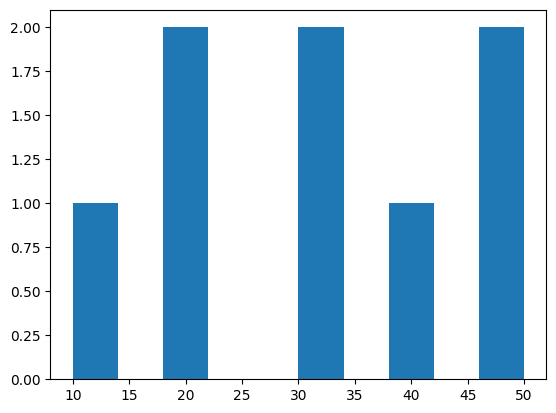

In [11]:
plt.hist(df['rating'])
plt.show()

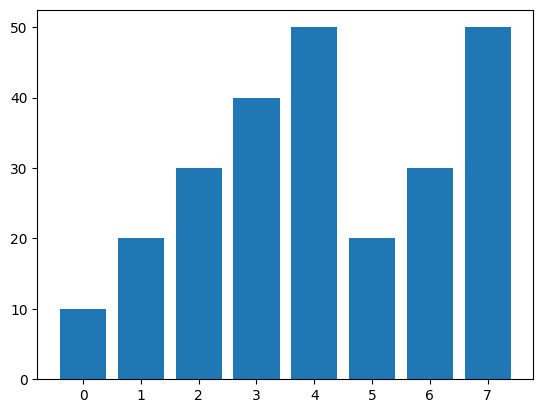

In [12]:
plt.bar(df.index, df['rating'])
plt.show()

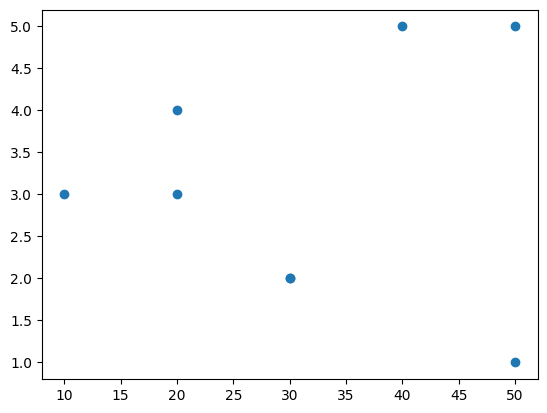

In [13]:
plt.plot(df['rating'], df['complaints'], 'o')
plt.show()

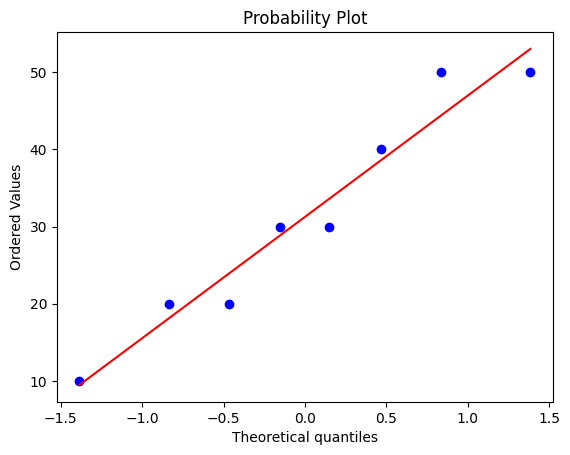

In [14]:
stats.probplot(df['rating'], dist="norm", plot=plt)
plt.show()

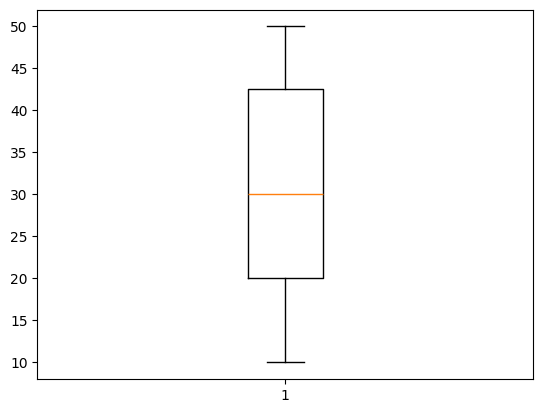

In [15]:
plt.boxplot(df['rating'])
plt.show()

### 2. 제어구문

In [16]:
A = True
B = False

if A:
    print("10")

10


In [17]:
if A:
    print("10")
else:
    print("20")

10


In [18]:
x = 40 if A else 20
print(x)

40


In [19]:
x=0
if A and B:
    x = 30
print(x)

0


In [20]:
for i in range(5):
    print(i)

0
1
2
3
4


In [21]:
i = 0
while i <= 6:
    i += 2
    print(i)

2
4
6
8


In [22]:
i = 0
while True:
    i += 1.5
    print(i)
    if i > 7:
        break

1.5
3.0
4.5
6.0
7.5


### 3. 사용자 정의 함수

In [23]:
def my_abs(x):
    if x < 0:
        x = -x
    return x

print(my_abs(-5), my_abs(5))

5 5


In [24]:
def normal_pdf(x, m=0, s=1):
    return((1/(np.sqrt(2*np.pi)*s))*np.exp(-(x-m)**2/(2*s**2)))


print(normal_pdf(1), normal_pdf(3))

0.24197072451914337 0.0044318484119380075


In [25]:
print(normal_pdf(1,2,1))

0.24197072451914337


In [26]:
def myregression(Y, X):
    Y = np.array(Y)
    X = np.array(X)
    n = X.shape[0]
    p = X.shape[1]
    X1 = np.hstack([np.ones((n,1)), X])
    beta = np.linalg.inv(X1.T @ X1) @ X1.T @ Y
    hatY = X1 @ beta
    SSE = np.sum((Y - hatY)**2)
    SSR = np.sum((hatY - np.mean(Y))**2)
    SST = SSE + SSR
    MSE = SSE/(n - p - 1)
    MSR = SSR/p
    f_val = MSR / MSE
    r_val = SSR / (SSR + SSE)
    p_val = 1 - f.cdf(f_val, p, n - p - 1)
    return {
        "coefficents": beta,
        "SSE": SSE,
        "SSR": SSR,
        "SST": SST,
        "MSE": MSE,
        "MSR": MSR,
        "dfR": p,
        "dfE": n - p - 1,
        "F": f_val,
        "Rsq": r_val,
        "p": p_val
    }

In [27]:
X1 = np.array([1.2, 2.3, 2.8, 3.1, 4.0, 2.1, 2.9, 3.5, 4.2, 4.9]).reshape(-1,2)
Y = np.array(range(5))
myregression(Y, X1)

{'coefficents': array([-2.58205611,  0.73321211,  0.74457722]),
 'SSE': np.float64(1.357773736848941),
 'SSR': np.float64(8.642226263151063),
 'SST': np.float64(10.000000000000004),
 'MSE': np.float64(0.6788868684244705),
 'MSR': np.float64(4.321113131575531),
 'dfR': 2,
 'dfE': 2,
 'F': np.float64(6.364997369302152),
 'Rsq': np.float64(0.8642226263151059),
 'p': np.float64(0.13577737368489406)}

In [28]:
reg_dict = myregression(Y, X1)

In [29]:
reg_dict['SSE']

np.float64(1.357773736848941)

In [30]:
reg_dict['coefficents']

array([-2.58205611,  0.73321211,  0.74457722])

In [31]:
reg_dict['Rsq']

np.float64(0.8642226263151059)

### 실습1

In [32]:
from scipy.stats import t

def two_sample_t_test(x, y, alternative='two-sided', d0=0):
    x = np.array(x)
    y = np.array(y)
    n1 = len(x)
    n2 = len(y)
    xbar1 = np.mean(x)
    xbar2 = np.mean(y)
    s1 = np.var(x, ddof=1)
    s2 = np.var(y, ddof=1)
    T = (xbar1 - xbar2 - d0) / np.sqrt(s1/n1 + s2/n2)
    df_num = (s1/n1 + s2/n2)**2
    df_den = (s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1)
    df = df_num / df_den

    def dist(n1, n2, x, df):
        if n1 > 30 and n2 > 30:
            return norm.cdf(x, df)
        else:
            return t.cdf(x, df)
    if alternative == 'two-sided':
        p_value = 2 * (1 - dist(n1, n2, abs(T), df))
        print("H0 : mu1 - mu2 = ", d0)
        print("H1 : mu1 - mu2 != ", d0)
    elif alternative == 'greater':
        p_value = 1 - dist(n1, n2, T, df)
        print("H0 : mu1 - mu2 = ", d0)
        print("H1 : mu1 - mu2 > ", d0)
    elif alternative == 'less':
        p_value = dist(n1, n2, T, df)
        print("H0 : mu1 - mu2 = ", d0)
        print("H1 : mu1 - mu2 < ", d0)

    print("T 통계량: ", T)
    print("p value: ", p_value)
    if p_value < 0.05:
        print("결론: 유의수준 0.05에서 기각할 수 있다.")
    else:
        print("결론: 유의수준 0.05에서 기각할 수 없다.")
    return T, df, p_value

In [33]:
# input 예시
np.random.seed(2000)
x1 = np.random.normal(0, 1, 20)
x2 = np.random.normal(1, 1, 30)

# 양측검정 예시
result = two_sample_t_test(x1, x2, alternative='two-sided')
print("\n")

# 단측가설 < 예시
result = two_sample_t_test(x1, x2, alternative='less')
print("\n")

# 단측가설 > 예시
result = two_sample_t_test(x1, x2, alternative='greater')
print("\n")

H0 : mu1 - mu2 =  0
H1 : mu1 - mu2 !=  0
T 통계량:  -2.882511680559821
p value:  0.005988110911543831
결론: 유의수준 0.05에서 기각할 수 있다.


H0 : mu1 - mu2 =  0
H1 : mu1 - mu2 <  0
T 통계량:  -2.882511680559821
p value:  0.002994055455771886
결론: 유의수준 0.05에서 기각할 수 있다.


H0 : mu1 - mu2 =  0
H1 : mu1 - mu2 >  0
T 통계량:  -2.882511680559821
p value:  0.9970059445442281
결론: 유의수준 0.05에서 기각할 수 없다.




### 4. 선형회귀모형

In [34]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [35]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [36]:
import seaborn as sns
corr_matrix = df.corr()
print(corr_matrix)

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

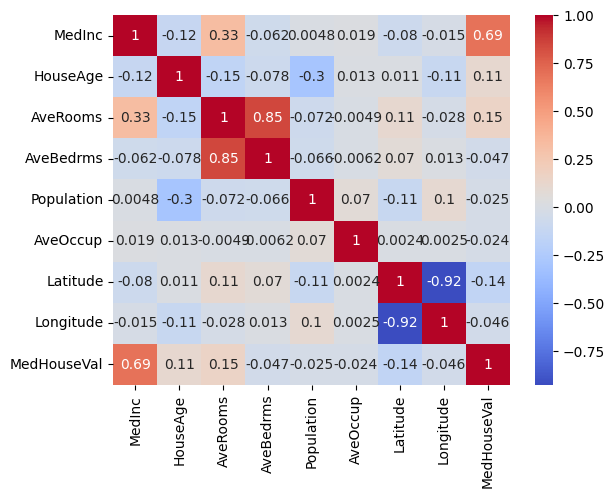

In [37]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

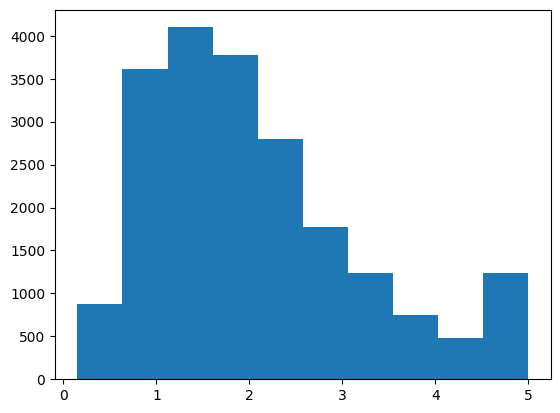

In [38]:
plt.hist(df['MedHouseVal'])
plt.show()

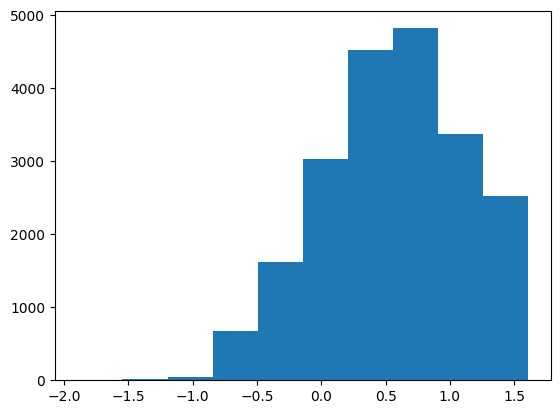

In [39]:
df['LOG_MedHouseVal'] = np.log(df['MedHouseVal'])
plt.hist(df['LOG_MedHouseVal'])
plt.show()

In [40]:
import statsmodels.api as sm

X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']]
y = df['LOG_MedHouseVal']
X = sm.add_constant(X)
model1 = sm.OLS(y, X).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        LOG_MedHouseVal   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     4109.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:58:30   Log-Likelihood:                -7819.3
No. Observations:               20640   AIC:                         1.566e+04
Df Residuals:                   20631   BIC:                         1.573e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -24.2459      0.322    -75.393      0.000     -24.876     -23.616
MedInc         0.1870      0.002     91.271      0.000       0.183       0.191
HouseAge       0.0023      0.000     10.726      0.000       0.002       0.003
AveRooms      -0.0333      0.003    -11.594      0.000      -0.039      -0.028
AveBedrms      0.2344      0.014     17.068      0.000       0.207       0.261
Population  7.843e-06   2.32e-06      3.384      0.001     3.3e-06    1.24e-05
AveOccup      -0.0017      0.000     -7.039      0.000      -0.002      -0.001
Latitude      -0.2845      0.004    -80.984      0.000      -0.291      -0.278
Longitude     -0.2850      0.004    -77.525      0.000      -0.292      -0.278
==============================================================================
Omnibus:                      803.061   Durbin-Watson:                   0.809
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2517.584
Skew:                          -0.036   Prob(JB):                         0.00
Kurtosis:                       4.709   Cond. No.                     2.38e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.38e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
X2 = df[['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup',
        'Longitude']]
X2 = sm.add_constant(X2)
model2 = sm.OLS(y, X2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        LOG_MedHouseVal   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     3018.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:58:30   Log-Likelihood:                -11151.
No. Observations:               20640   AIC:                         2.232e+04
Df Residuals:                   20633   BIC:                         2.237e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4807      0.174     -2.763      0.006      -0.822      -0.140
MedInc         0.2102      0.002    130.106      0.000       0.207       0.213
HouseAge       0.0075      0.000     30.562      0.000       0.007       0.008
AveRooms      -0.0161      0.001    -12.832      0.000      -0.019      -0.014
Population  2.956e-05   2.71e-06     10.913      0.000    2.42e-05    3.49e-05
AveOccup      -0.0023      0.000     -8.317      0.000      -0.003      -0.002
Longitude     -0.0006      0.001     -0.436      0.663      -0.003       0.002
==============================================================================
Omnibus:                      444.490   Durbin-Watson:                   0.720
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1001.529
Skew:                           0.002   Prob(JB):                    3.32e-218
Kurtosis:                       4.079   Cond. No.                     1.10e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.1e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [42]:
residuals = model1.resid
residuals.head()

,0
0,0.034111
1,-0.180357
2,-0.023588
3,0.161104
4,0.512605


In [ ]:
# 오래 걸리는게 정상입니다.
influence = model1.get_influence()
sf = influence.summary_frame()
sf.head()

In [ ]:
standard_resid = sf['standard_resid']
student_resid = sf['student_resid']

In [ ]:
plt.scatter(model1.fittedvalues, sf['student_resid'])
plt.axhline(y=0, color='red')
plt.show()

In [ ]:
fig = sm.graphics.plot_regress_exog(model1, 'MedInc')
plt.show()

In [ ]:
fig2 = sm.graphics.plot_regress_exog(model1, 'Population')
plt.show()

In [ ]:
outliers = influence.cov_ratio < 1
df_no_out = df[~outliers]
X_no_out = df_no_out.drop(columns=['MedHouseVal', 'LOG_MedHouseVal'])
y_no_out = df_no_out['LOG_MedHouseVal']
X_no_out = sm.add_constant(X_no_out)
model_no_out = sm.OLS(y_no_out, X_no_out).fit()

In [ ]:
fig3 = sm.qqplot(model1.resid, line='45', fit=True)
plt.show()

In [ ]:
fig3 = sm.qqplot(model_no_out.resid, line='45', fit=True)
plt.show()

In [ ]:
summary1 = model1.summary()
summary2 = model_no_out.summary()

In [ ]:
summary1

In [ ]:
summary2

In [ ]:
conf_int_no_out = model_no_out.conf_int(alpha=0.05)
conf_int_no_out

In [ ]:
newdata = pd.DataFrame({
    'const': [1],
    'MedInc': [4],
    'HouseAge': [20],
    'AveRooms': [5],
    'AveBedrms': [1],
    'Population': [1000],
    'AveOccup': [3],
    'Latitude': [34],
    'Longitude': [-118]
})

pred_conf = model_no_out.predict(newdata)

In [ ]:
pred_conf

### 실습2

In [ ]:
import seaborn as sns
tips = sns.load_dataset('tips')
tips

In [ ]:
import seaborn as sns
mpg = sns.load_dataset('mpg')
mpg

In [ ]:
import statsmodels.api as sm
longley = sm.datasets.longley.load_pandas().data
longley

### 5. 선형회귀모형의 변수선택

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, LogisticRegression
from mlxtend.feature_selection import ExhaustiveFeatureSelector
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report, accuracy_score

In [ ]:
# 데이터세트: California Housing 데이터 사용
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
print("California Housing 데이터셋 상위 5개:")
print(df.head())

In [ ]:
# =============================================================================
# 데이터 분할: training set과 test set 나누기 (70%:30%)
# =============================================================================
np.random.seed(1)
train, test = train_test_split(df, test_size=0.3, random_state=1)
print("\nTraining set shape:", train.shape)
print("Test set shape:", test.shape)

In [ ]:
# =============================================================================
# 전체 선형 회귀 모형 적합 (statsmodels 사용)
# =============================================================================
# X와 y 분리 (상수항 추가)
X_train = train.drop("MedHouseVal", axis=1)
y_train = train["MedHouseVal"]
X_test = test.drop("MedHouseVal", axis=1)
y_test = test["MedHouseVal"]
X_train_const = sm.add_constant(X_train)
full_model = sm.OLS(y_train, X_train_const).fit()
print("\n전체 선형 회귀 모형 요약:")
print(full_model.summary())

In [ ]:
# 전진 선택법 (AIC 기준)
def forward_selection_simple(data, target, max_features=None):
    """
    - data: 설명변수 DataFrame
    - target: 반응변수 Series
    - max_features: 선택할 최대 변수 수 (없으면 None)
    """
    selected = []  # 선택된 변수 리스트
    remaining = list(data.columns)  # 아직 선택되지 않은 변수 목록
    current_score = np.inf  # 현재 모델 AIC (작을수록 좋음)

    # 남은 변수가 있고 선택 변수 수가 제한 내라면 반복
    while remaining and (max_features is None or len(selected) < max_features):
        scores = []  # 각 후보 변수 추가 시 AIC 점수 저장
        for feature in remaining:
            features = selected + [feature]
            X = sm.add_constant(data[features])
            model = sm.OLS(target, X).fit()
            scores.append((model.aic, feature))
        # 가장 낮은 AIC를 주는 후보 선택
        scores.sort()
        best_score, best_feature = scores[0]
        if best_score < current_score:
            selected.append(best_feature)      # 후보 변수를 선택 변수에 추가
            remaining.remove(best_feature)       # 후보 목록에서 제거
            current_score = best_score           # 현재 AIC 업데이트
        else:
            break  # 더 이상 개선이 없으면 종료
    return selected, current_score

In [ ]:
# 후진 소거법(BIC 또는 AIC)
def backward_elimination_simple(data, target, criterion='bic'):
    """
    - data: 설명변수 DataFrame
    - target: 반응변수 Series
    - criterion: 'bic' 또는 'aic' (기본은 'bic')
    """
    selected = list(data.columns)  # 처음에는 모든 변수를 선택
    current_model = sm.OLS(target, sm.add_constant(data[selected])).fit()
    current_score = current_model.bic if criterion=='bic' else current_model.aic

    improved = True
    while improved and len(selected) > 1:
        scores = []
        for feature in selected:
            # 하나씩 제거하면서 모형 적합
            temp_features = [f for f in selected if f != feature]
            X = sm.add_constant(data[temp_features])
            model = sm.OLS(target, X).fit()
            score = model.bic if criterion=='bic' else model.aic
            scores.append((score, feature))
        scores.sort()
        best_score, worst_feature = scores[0]
        if best_score < current_score:
            selected.remove(worst_feature)  # 제거한 변수를 최종 선택에서 제외
            current_score = best_score       # AIC/BIC 업데이트
        else:
            improved = False  # 더 이상 개선이 없으면 종료
    return selected, current_score

In [ ]:
# 전진 선택법 (AIC 기준, 최대 9개 변수 고려)
selected_forward, aic_forward = forward_selection_simple(X_train, y_train, max_features=6)
print("\n전진 선택법 (AIC 기준) 선택된 변수들:")
print(selected_forward)
print("최종 AIC:", aic_forward)

In [ ]:
# 후진 소거법 (BIC 기준)
selected_backward_bic, bic_backward = backward_elimination_simple(X_train, y_train, criterion='bic')
print("\n후진 소거법 (BIC 기준) 선택된 변수들:")
print(selected_backward_bic)
print("최종 BIC:", bic_backward)

In [ ]:
# 후진 소거법 (AIC 기준)
selected_backward_aic, aic_backward = backward_elimination_simple(X_train, y_train, criterion='aic')
print("\n후진 소거법 (AIC 기준) 선택된 변수들:")
print(selected_backward_aic)
print("최종 AIC:", aic_backward)

In [ ]:
# # 매우 오래 걸리므로 웬만해서는 실행하지 말 것.
# sigma2 = full_model.mse_resid
# n = X_train_const.shape[0]
# features = list(X_train.columns)

# results = []
# for k in range(1, len(features) + 1):
#     for subset in itertools.combinations(features, k):
#         X_sub = sm.add_constant(X_train[list(subset)])
#         model = sm.OLS(y_train, X_sub).fit()
#         sse = np.sum(model.resid ** 2)
#         p = len(model.params)
#         Cp = sse / sigma2 - (n - 2 * p)
#         results.append({
#             'features': subset,
#             'adjR2': model.rsquared_adj,
#             'Cp': Cp,
#             'model': model
#         })

# results_df = pd.DataFrame(results)

# best_adjR2 = results_df.loc[results_df['adjR2'].idxmax()]
# best_Cp = results_df.loc[results_df['Cp'].idxmin()]

# print("Best subset by adjusted R²:")
# print("Features:", best_adjR2['features'], "Adjusted R²:", best_adjR2['adjR2'])
# print("\nBest subset by Mallows' Cp:")
# print("Features:", best_Cp['features'], "Cp:", best_Cp['Cp'])


In [ ]:
# -----------------------------------------------------------------------------
# 최적부분집합 선택 1: Validation set을 이용한 방법
# -----------------------------------------------------------------------------
# Training set 내에서 validation set과 hold-out set으로 분할 (랜덤하게 True/False)
np.random.seed(1)
val_mask = np.random.choice([True, False], size=X_train.shape[0])
X_val = X_train[val_mask]
y_val = y_train[val_mask]
X_hold = X_train[~val_mask]
y_hold = y_train[~val_mask]

max_features = 8
val_errors = []

In [ ]:
# ExhaustiveFeatureSelector를 사용하여 각 변수 개수별로 최적의 부분집합 선택
for k in range(1, max_features + 1):
    # fixed number of features,  min = max = k
    efs = ExhaustiveFeatureSelector(LinearRegression(),
                                    min_features=k,
                                    max_features=k,
                                    scoring='neg_mean_squared_error',
                                    print_progress=False,
                                    cv=3)  # 내부 CV로 모델 평가 (여기서는 3-fold)
    efs = efs.fit(X_val.values, y_val.values)
    best_idx = efs.best_idx_
    best_features = [X_val.columns[i] for i in best_idx]
    # Fit model on validation set with selected features and evaluate on hold-out set
    X_hold_subset = sm.add_constant(X_hold[best_features])
    model = sm.OLS(y_hold, X_hold_subset).fit()
    # 예측 및 MSE 계산
    pred = model.predict(X_hold_subset)
    mse = mean_squared_error(y_hold, pred)
    val_errors.append(mse)

val_errors = np.array(val_errors)
print("\nValidation set을 이용한 각 변수 개수별 MSE:")
print(val_errors)
best_k_val = np.argmin(val_errors) + 1  # 인덱스는 0부터 시작하므로 +1
print("최소 MSE를 주는 변수 개수 (Validation):", best_k_val)

In [ ]:
# 해당 변수 개수의 최적 부분집합 선택 결과 (모델 계수 출력)
efs = ExhaustiveFeatureSelector(LinearRegression(),
                                min_features=int(best_k_val),
                                max_features=int(best_k_val),
                                scoring='neg_mean_squared_error',
                                print_progress=False,
                                cv=3)
efs = efs.fit(X_train.values, y_train.values)
best_features_val = [X_train.columns[i] for i in efs.best_idx_]
X_train_subset = sm.add_constant(X_train[best_features_val])
model_val = sm.OLS(y_train, X_train_subset).fit()
print("\n[Validation Set 기준] 선택된 변수들 (최적 부분집합):")
print(best_features_val)
print("\n모델 계수:")
print(model_val.params)

In [ ]:
# -----------------------------------------------------------------------------
# 최적부분집합 선택 2: Cross-Validation(CV)을 이용한 방법
# -----------------------------------------------------------------------------
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=123)
cv_errors = np.zeros((k, max_features))

# 각 fold 별로, 변수 개수 1~max_features에 대해 MSE 계산
for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_tr, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    for k_features in range(1, max_features + 1):
        efs = ExhaustiveFeatureSelector(LinearRegression(),
                                        min_features=k_features,
                                        max_features=k_features,
                                        scoring='neg_mean_squared_error',
                                        print_progress=False,
                                        cv=3)
        efs = efs.fit(X_tr.values, y_tr.values)
        best_idx = efs.best_idx_
        best_feats = [X_tr.columns[i] for i in best_idx]
        # 모델 학습 및 예측
        X_v_subset = sm.add_constant(X_v[best_feats])
        model_cv = sm.OLS(y_v, X_v_subset).fit()
        pred_cv = model_cv.predict(X_v_subset)
        mse_cv = mean_squared_error(y_v, pred_cv)
        cv_errors[fold, k_features - 1] = mse_cv

In [ ]:
mean_cv_errors = cv_errors.mean(axis=0)
print("\nCV를 이용한 각 변수 개수별 평균 MSE:")
print(mean_cv_errors)
best_k_cv = np.argmin(mean_cv_errors) + 1
print("최소 평균 MSE를 주는 변수 개수 (CV):", best_k_cv)

In [ ]:
# -----------------------------------------------------------------------------
# 변수 선택 방법들의 비교
# -----------------------------------------------------------------------------.
def evaluate_model(features, X_train, y_train, X_test, y_test):
    X_train_sub = sm.add_constant(X_train[features])
    X_test_sub = sm.add_constant(X_test[features])
    model = sm.OLS(y_train, X_train_sub).fit()
    train_pred = model.predict(X_train_sub)
    test_pred = model.predict(X_test_sub)
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    return len(features), train_mse, test_mse

In [ ]:
# 전체 모델 (모든 변수)
all_features = list(X_train.columns)
full_model_eval = evaluate_model(all_features, X_train, y_train, X_test, y_test)

# Validation set 기반 최적부분집합 모델
val_model_eval = evaluate_model(best_features_val, X_train, y_train, X_test, y_test)

# CV 기반 최적부분집합 모델: Validation과 CV에서 선택한 변수 개수가 다를 수 있으므로,
# CV에서는 다시 ExhaustiveFeatureSelector를 사용하여 전체 데이터를 대상으로 선택
efs_cv = ExhaustiveFeatureSelector(LinearRegression(),
                                   min_features=int(best_k_cv),
                                   max_features=int(best_k_cv),
                                   scoring='neg_mean_squared_error',
                                   print_progress=False,
                                   cv=5)
efs_cv = efs_cv.fit(X_train.values, y_train.values)
best_features_cv = [X_train.columns[i] for i in efs_cv.best_idx_]
cv_model_eval = evaluate_model(best_features_cv, X_train, y_train, X_test, y_test)

In [ ]:
# 결과 테이블 작성
methods = ["Full Model", "Best Subset (Validation)", "Best Subset (CV)"]
m_table = pd.DataFrame(columns=["# var", "training err", "test err"],
                       index=methods)

m_table.loc["Full Model"] = full_model_eval
m_table.loc["Best Subset (Validation)"] = val_model_eval
m_table.loc["Best Subset (CV)"] = cv_model_eval

print("\n변수 선택 방법들의 비교:")
print(m_table)

### 실습3

In [ ]:
# Forward selection function (AIC 기준)
def forward_selection_simple(data, target, max_features=None):
    selected = []
    remaining = list(data.columns)
    current_score = np.inf
    while remaining and (max_features is None or len(selected) < max_features):
        scores = []
        for feature in remaining:
            features = selected + [feature]
            X = sm.add_constant(data[features])
            model = sm.OLS(target, X).fit()
            scores.append((model.aic, feature))
        scores.sort()
        best_score, best_feature = scores[0]
        if best_score < current_score:
            selected.append(best_feature)
            remaining.remove(best_feature)
            current_score = best_score
        else:
            break
    return selected, current_score

# ===================== Longley Dataset (Y = Employed ~ TOTEMP 대용) =====================
longley = sm.datasets.longley.load_pandas().data
# Using 'Employed' as Y (TOTEMP equivalent)
X_long = longley.drop("TOTEMP", axis=1)
y_long = longley["TOTEMP"]
# All numeric; no dummies needed.
X_train, X_test, y_train, y_test = train_test_split(X_long, y_long, test_size=0.3, random_state=42)
sel_long, _ = forward_selection_simple(X_train, y_train, max_features=5)
X_train_sel = sm.add_constant(X_train[sel_long])
X_test_sel  = sm.add_constant(X_test[sel_long])
model_long = sm.OLS(y_train, X_train_sel).fit()
pred_long = model_long.predict(X_test_sel)
rmse_long = np.sqrt(mean_squared_error(y_test, pred_long))
r2_long = model_long.rsquared
print("Longley - Selected vars:", sel_long)
print("Longley - RMSE:", rmse_long, "R2:", r2_long)

### 6. 로지스틱 회귀모형

In [ ]:
german = fetch_openml("credit-g", version=1, as_frame=True)
german_df = german.frame.drop('class', axis = 1)
german_y = german.target

print(german_df.head())

In [ ]:
print(german_y)

In [ ]:
# Logistic regression 1 - logistic regression 함수 사용하기

german_df = pd.get_dummies(german_df, drop_first=True)

# Training, Test set 분할 (70%:30%)
X_train, X_test, y_train, y_test = train_test_split(german_df, german_y, test_size=0.3, random_state=42, stratify=german_y)

# Feature scaling: 표준화 (로지스틱 회귀는 스케일에 민감할 수 있음)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Logistic Regression 모형 적합
logreg = LogisticRegression(solver='liblinear', random_state=42)
logreg.fit(X_train_scaled, y_train)

# Test set에 대해 예측
y_pred = logreg.predict(X_test_scaled)

In [ ]:
# 평가: 혼동행렬, 정확도, 분류 보고서 출력
cm = confusion_matrix(y_test, y_pred)
print("\n혼동행렬:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("\n정확도:", accuracy)

print("\n분류 보고서:")
print(classification_report(y_test, y_pred))

In [ ]:
# Logistic regression 2 - GLM에서 binomial을 family로 사용하기

# 전체 설명변수를 formula에 포함시키기 위해, 'class'를 제외한 변수들을 가져옴
predictors = german_df.copy()
german_df['class_'] = german_y.apply(lambda x: 1 if x.lower() == "good" else 0)
# 변수 이름에 공백이나 식별자로 사용하기 어려운 문자가 있으면 Q()로 감싸서 안전하게 처리
safe_predictors = []
for col in predictors:
    if not col.isidentifier():
        safe_predictors.append(f"Q('{col}')")
    else:
        safe_predictors.append(col)

# formula 작성: 모든 설명변수를 포함
formula = "class_ ~ " + " + ".join(safe_predictors)
print("\n작성된 formula:")
print(formula)

In [ ]:

# GLM을 이용한 Logistic Regression 모형 적합
# family는 statsmodels.api.sm.families.Binomial() 사용
glm_model = smf.glm(formula=formula, data=german_df, family=sm.families.Binomial()).fit()

# 모형 요약 출력
print("\nGLM을 이용한 Logistic Regression 모형 요약:")
print(glm_model.summary())

### 실습4

In [ ]:
from sklearn.datasets import load_breast_cancer

# 유방암 데이터세트 (이진 분류)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("유방암 데이터셋 상위 5개:")
print(df.head())

# 클래스 분포 확인 (0: 악성, 1: 양성)
print("\n클래스 분포:")
print(df['target'].value_counts())

In [ ]:
# sklearn Logistic Regression
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
logreg = LogisticRegression(solver='liblinear', random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
print("\n[sklearn] 혼동행렬:")
print(cm)
print("\n[sklearn] 정확도:", accuracy_score(y_test, y_pred))
print("\n[sklearn] 분류 보고서:")
print(classification_report(y_test, y_pred))

In [ ]:
# statsmodels GLM Logistic Regression
predictors = X.columns

safe_predictors = []
for col in predictors:
    if not col.isidentifier():
        safe_predictors.append(f"Q('{col}')")
    else:
        safe_predictors.append(col)
formula = "target ~ " + " + ".join(safe_predictors)

print("\n작성된 formula:")
print(formula)
glm_model = smf.glm(formula=formula, data=df, family=sm.families.Binomial()).fit()
print("\n[statsmodels GLM] 모형 요약:")
print(glm_model.summary())